In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sklearn
print(sklearn.__version__)

1.9.0


In [94]:
import sys
print(sys.executable)

c:\Users\saipr\anaconda3\python.exe


In [2]:
import sys 
!{sys.executable} -m pip install -U scikit-learn


In [98]:
import sys
import sklearn

print("Python:", sys.executable)
print("Sklearn:", sklearn.__version__)

Python: c:\Users\saipr\anaconda3\python.exe
Sklearn: 1.6.1


In [3]:
df = pd.read_csv(r"C:\EXCEL DATA\Insurance1.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [11]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [12]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [13]:
df.shape

(1338, 7)

In [14]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

In [17]:
df['sex'] = label_encoder.fit_transform(df['sex'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


<Axes: ylabel='charges'>

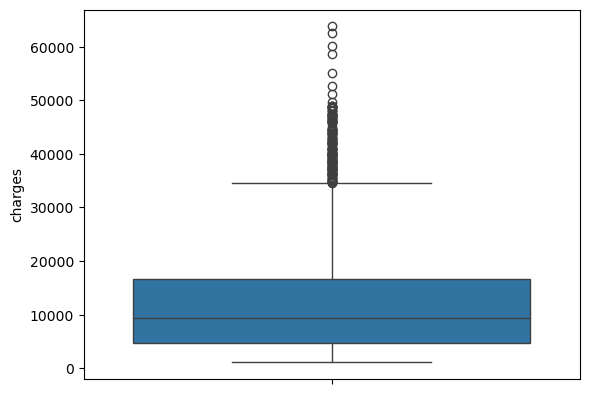

In [18]:
sns.boxplot(df['charges'])

Text(0.5, 1.0, 'The number of smoker and Non-smokers (18 years old)')

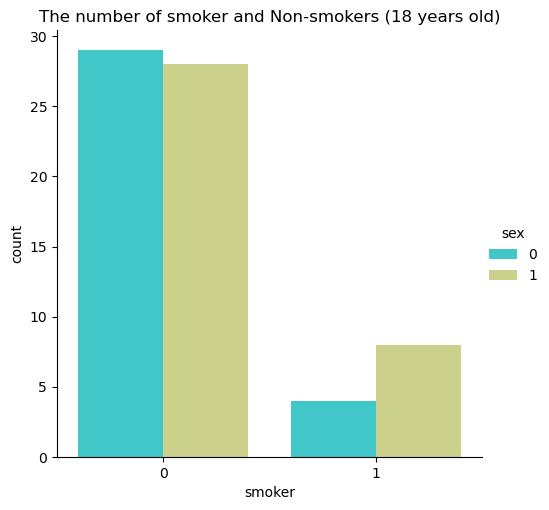

In [19]:
sns.catplot(x="smoker", kind="count", hue='sex', palette="rainbow", data=df[(df.age == 18)])

plt.title("The number of smoker and Non-smokers (18 years old)")

C:\Users\saipr\AppData\Local\Temp\ipykernel_26812\2451496599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="smoker", x="charges", data=df[(df.age==18)] , orient="h", palette= 'pink')


<Axes: title={'center': 'charges for 18 year old smokers'}, xlabel='charges', ylabel='smoker'>

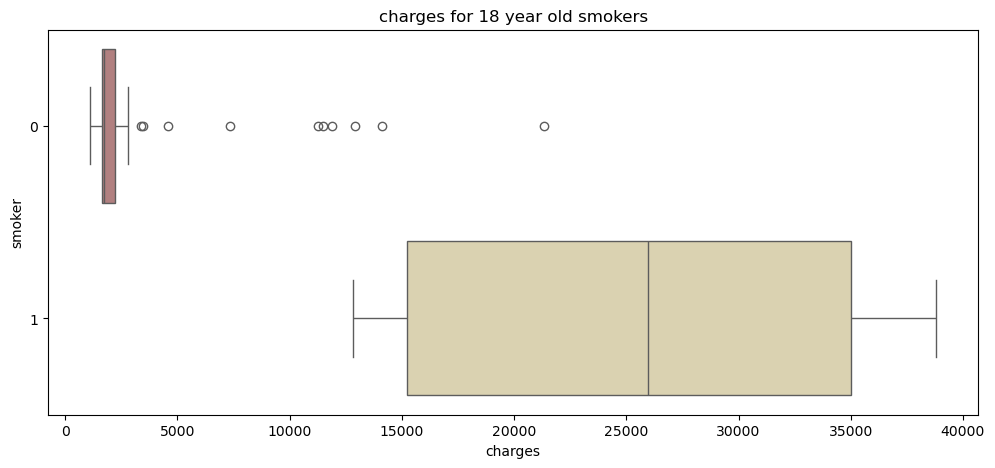

In [20]:
plt.figure(figsize=(12,5))
plt.title("charges for 18 year old smokers")
sns.boxplot(y="smoker", x="charges", data=df[(df.age==18)] , orient="h", palette= 'pink')

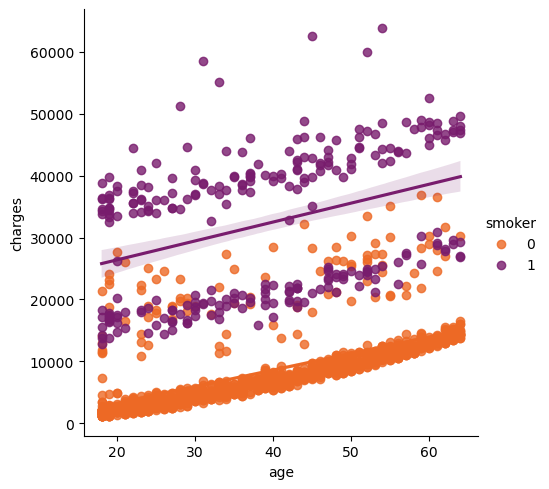

In [21]:
sns.lmplot(x='age', y='charges', hue='smoker',
           data=df, 
           palette = 'inferno_r')

<Axes: xlabel='charges', ylabel='Count'>

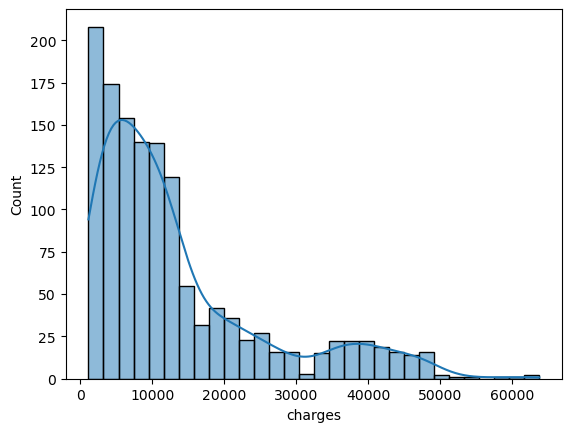

In [22]:
sns.histplot(data=df, x='charges', kde=True)

C:\Users\saipr\AppData\Local\Temp\ipykernel_26812\583450055.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(df['charges'], kde= True, color='c')


Text(0.5, 1.0, 'Distribution of charges')

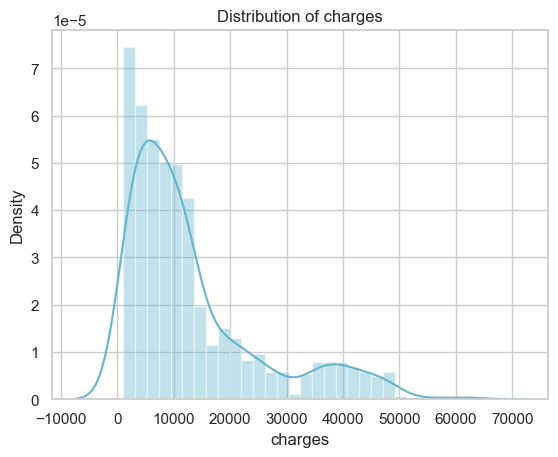

In [23]:
sns.set(style='whitegrid')
ax = sns.distplot(df['charges'], kde= True, color='c')
plt.title('Distribution of charges')

In [26]:
charges = df['charges'].groupby(df['region']).sum().sort_values(ascending=True)
charges = charges.head()
print(charges)

region
southwest    4.012755e+06
northwest    4.035712e+06
northeast    4.343669e+06
southeast    5.363690e+06
Name: charges, dtype: float64


C:\Users\saipr\AppData\Local\Temp\ipykernel_26812\1792947436.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=charges.index, y=charges, palette='Blues')


<Axes: xlabel='region', ylabel='charges'>

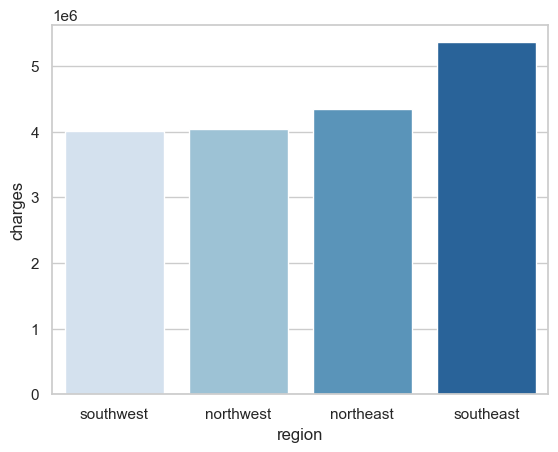

In [28]:
sns.barplot(x=charges.index, y=charges, palette='Blues')

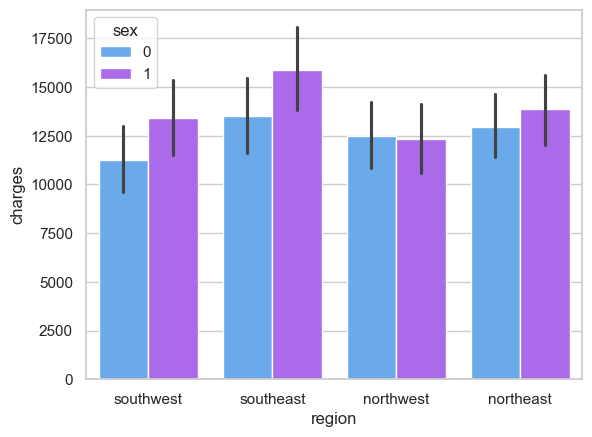

In [30]:
ax = sns.barplot(x='region', y='charges', hue='sex', 
                 data=df, palette='cool')

In [32]:
df['region'] = label_encoder.fit_transform(df['region'])

In [33]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [34]:
print(label_encoder.classes_)

[0 1 2 3]


<Axes: >

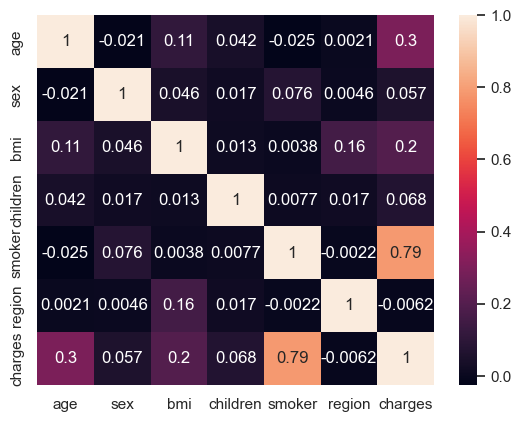

In [35]:
sns.heatmap(df.corr(), annot=True)

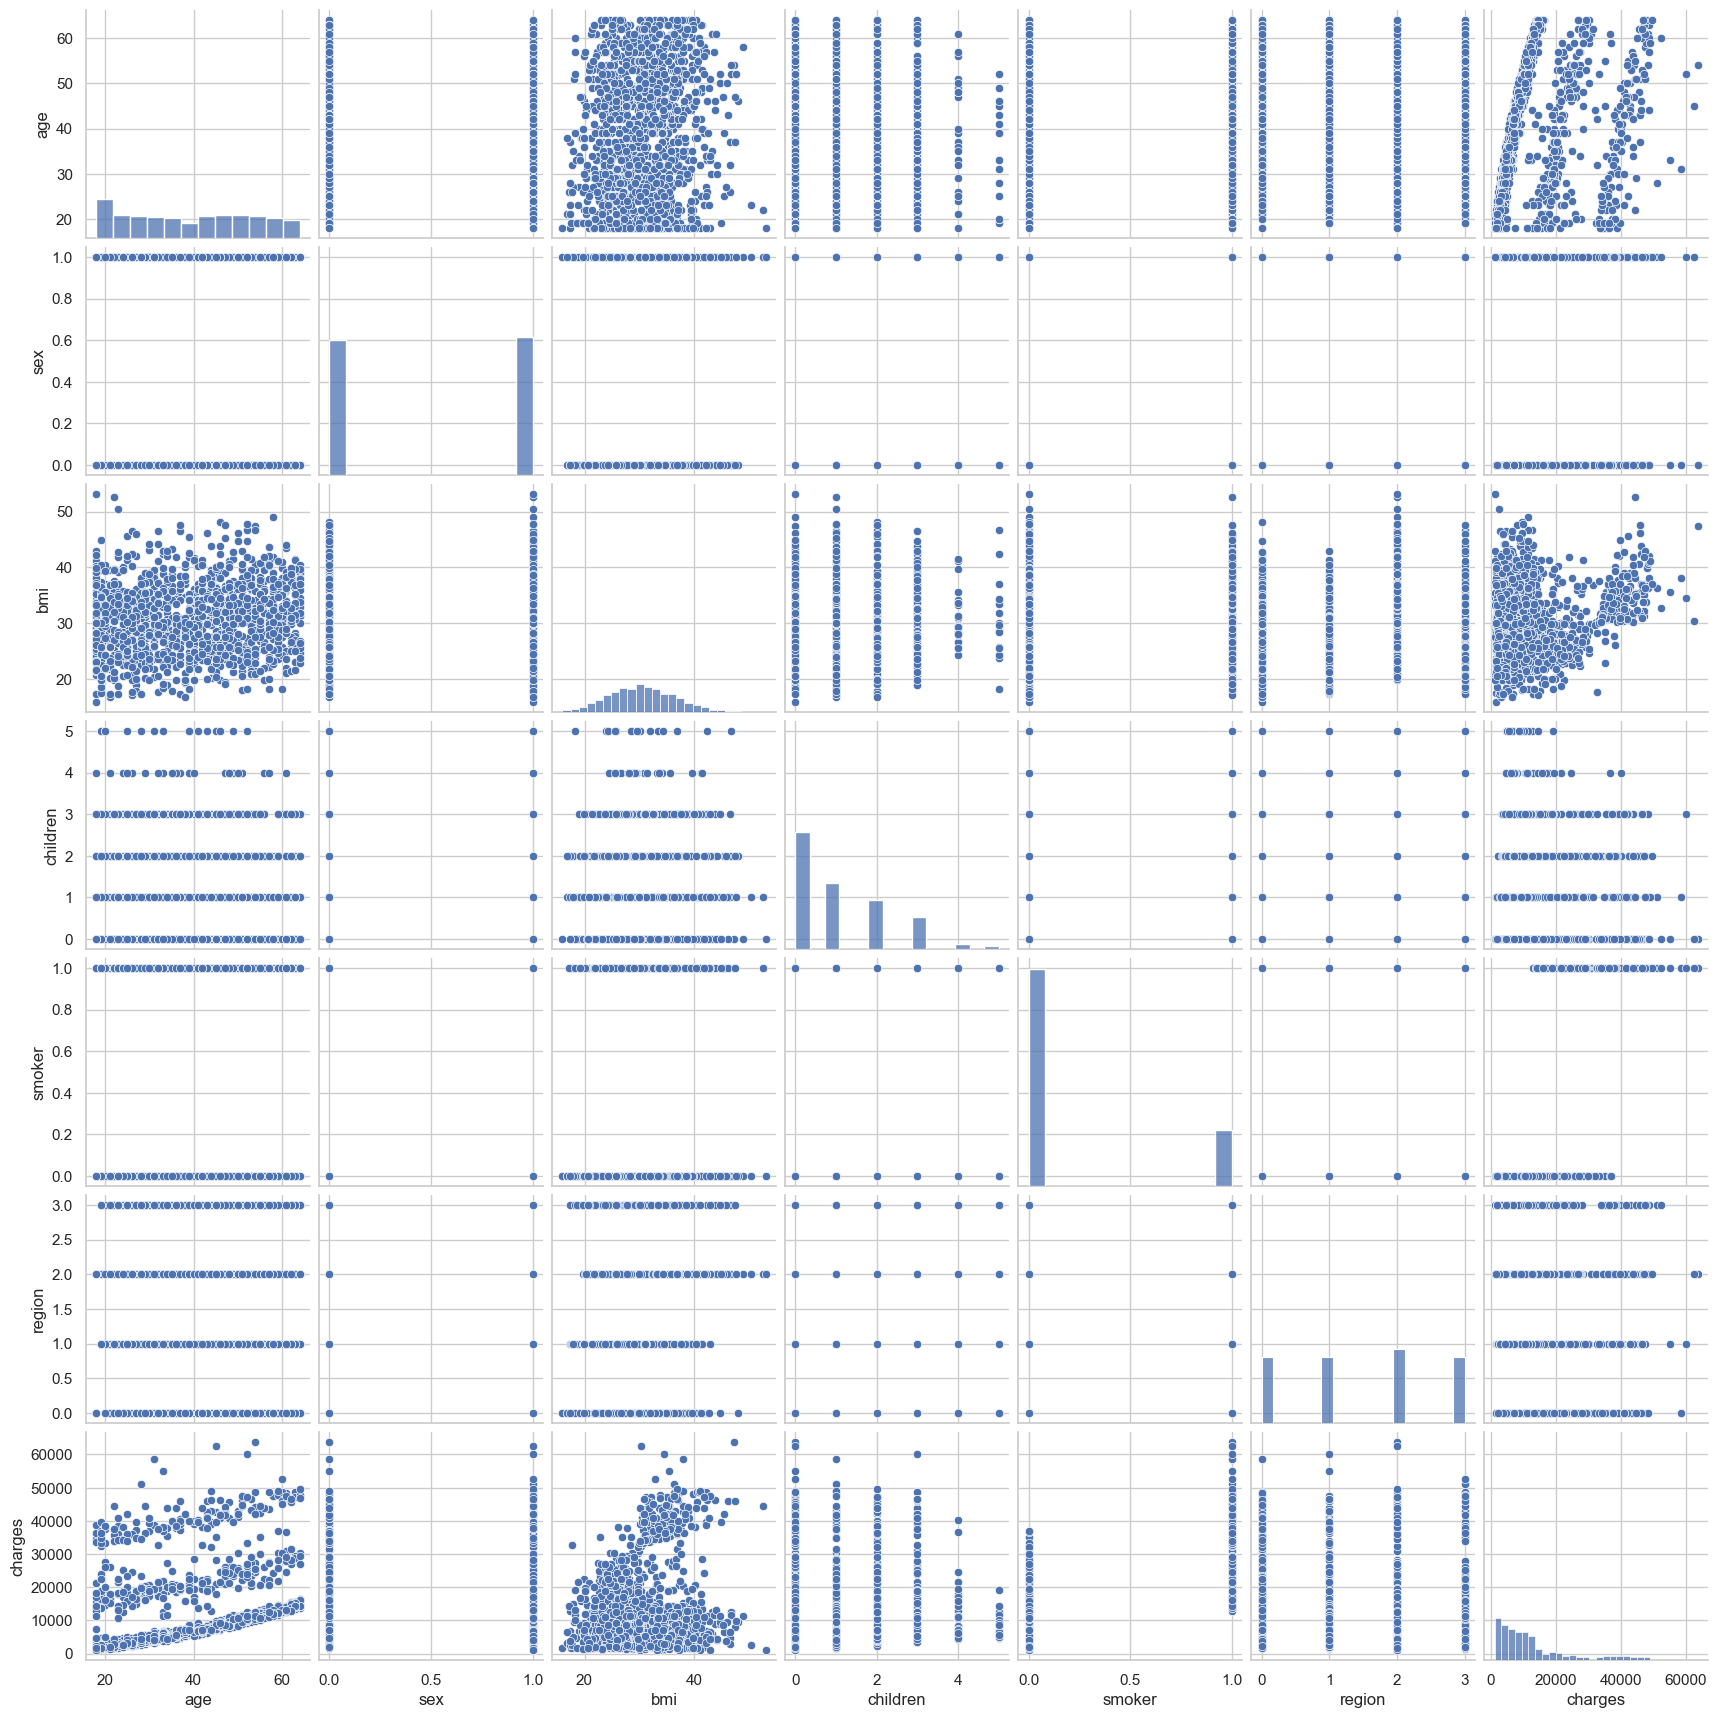

In [36]:
sns.pairplot(df)

In [37]:
from sklearn.model_selection import train_test_split
x = df.drop(['charges','region'], axis=1)
y = df['charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(x_train, y_train)

y_train_pred = lr.predict(x_train)
y_test_pred =lr.predict(x_test)

print(lr.score(x_test, y_test))
print(lr.score(x_train, y_train))


0.7811302113434095
0.7410888590280913


In [39]:
from sklearn.preprocessing import PolynomialFeatures

X = df.drop(['charges', 'region'], axis=1)
Y = df.charges

quad = PolynomialFeatures (degree = 2)
x_quad = quad.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(x_quad, Y, random_state=0)

plr = LinearRegression().fit(X_train, Y_train)

Y_train_pred = plr.predict(X_train)
Y_test_pred = plr.predict(X_test)

print(lr.score(x_train, y_train))
print(lr.score(x_test, y_test))
print(plr.score(X_test, Y_test))


0.7410888590280913
0.7811302113434095
0.8849197344147236


In [40]:
# COMPARE BETWEEN 2 MODELS

In [41]:
from sklearn.model_selection import train_test_split
x = df.drop(['charges','region'], axis=1)
y = df['charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import  GradientBoostingRegressor
from sklearn.tree  import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


In [43]:
models = {
    "LR" : LinearRegression(),
    "RF" : RandomForestRegressor(n_estimators=100, max_depth=7),
    "DT" : DecisionTreeRegressor(),
    "GradientBoosting" : GradientBoostingRegressor(n_estimators=100, max_depth=7),
    "KNN" : KNeighborsRegressor(),
    "SVR" : SVR()
}

In [44]:
for name, model in models.items():
    print(f'Training models {name} \n')

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f'Score is {model.score(x_test, y_test)}')

    #Use appropriate regression metrics

    print(f'Training R-squared : {r2_score(y_train, model.predict(x_train))}')
    print(f'Testing R-squared: {r2_score(y_test, y_pred)}')
    print(f'Mean squared Error {mean_squared_error(y_test, y_pred)}')
    print(f'Mean Absolute Error {mean_absolute_error(y_test, y_pred)}')

Training models LR 

Score is 0.7811302113434095
Training R-squared : 0.7410888590280913
Testing R-squared: 0.7811302113434095
Mean squared Error 33979257.05080822
Mean Absolute Error 4213.484797807139
Training models RF 

Score is 0.868649785398027
Training R-squared : 0.9227405229770778
Testing R-squared: 0.868649785398027
Mean squared Error 20391954.198128544
Mean Absolute Error 2506.158767421592
Training models DT 

Score is 0.7144822566838962
Training R-squared : 0.9983078124756305
Testing R-squared: 0.7144822566838962
Mean squared Error 44326267.468218915
Mean Absolute Error 3143.9312743880596
Training models GradientBoosting 

Score is 0.835952591339101
Training R-squared : 0.9895184589941435
Testing R-squared: 0.835952591339101
Mean squared Error 25468152.09911713
Mean Absolute Error 2764.7925892645108
Training models KNN 

Score is 0.19719816290911552
Training R-squared : 0.43656452248432975
Testing R-squared: 0.19719816290911552
Mean squared Error 124633966.84762521
Mean Abso

In [46]:
max_depth_values = [1,2,3,4,5,6,7,8]

train_accuracy_values = []

for max_depth_val in max_depth_values:
    model = RandomForestRegressor(max_depth = max_depth_val, random_state=2)

    model.fit(x_train, y_train)
    y_pred = model.predict(x_train)
    acc_train = model.score(x_test, y_test)
    train_accuracy_values.append(acc_train)

In [47]:
train_accuracy_values

[0.6608048922770777,
 0.8417933495550463,
 0.8675746825596274,
 0.8724203110331318,
 0.8736575902284198,
 0.8719465796448753,
 0.8701118366669915,
 0.8666083244133396]

In [49]:
final_model = RandomForestRegressor(max_depth = 6, random_state = 0)
final_model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of th

In [50]:
forest_train_pred = final_model.predict(x_train)
forest_test_pred = final_model.predict(x_test)

print('MSE train data : %.3f, MSE test data :%.3f' % (
mean_squared_error(y_train, forest_train_pred),
mean_squared_error(y_test, forest_test_pred)
))

print('R2 train data: %.3f, R2 test data: %.3f' % (
    r2_score(y_train,forest_train_pred),
    r2_score(y_test, forest_test_pred)
))

MSE train data : 14242536.777, MSE test data :20370729.879
R2 train data: 0.901, R2 test data: 0.869


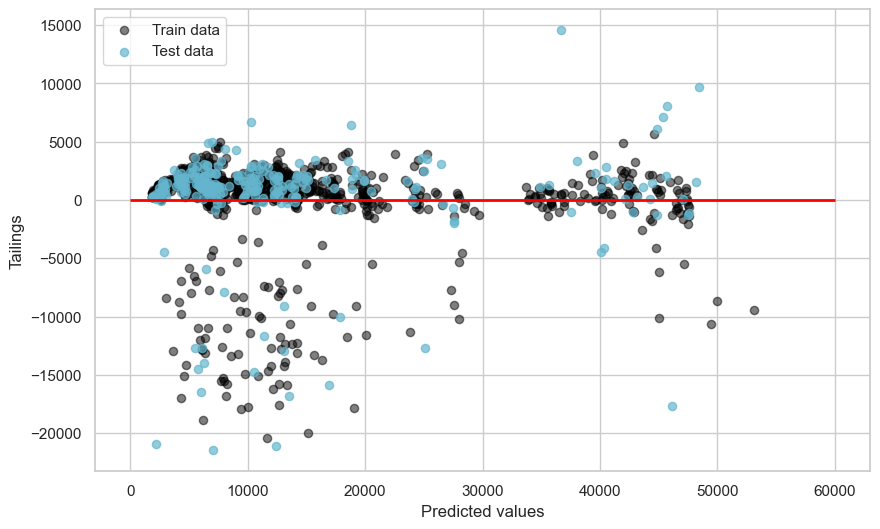

In [51]:
plt.figure(figsize=(10,6))

plt.scatter(forest_train_pred,forest_train_pred - y_train,
          c = 'black', marker = 'o', s = 35, alpha = 0.5,
          label = 'Train data')
plt.scatter(forest_test_pred,forest_test_pred - y_test,
          c = 'c', marker = 'o', s = 35, alpha = 0.7,
          label = 'Test data')
plt.xlabel('Predicted values')
plt.ylabel('Tailings')
plt.legend(loc = 'upper left')
plt.hlines(y = 0, xmin = 0, xmax = 60000, lw = 2, color = 'red')
plt.show()

In [53]:
lr = LinearRegression().fit(x_train, y_train)

y_train_pred = lr.predict(x_train)
y_test_pred = lr.predict(x_test)

print(lr.score(x_test, y_test))


0.7811302113434095


In [54]:
from sklearn.preprocessing import PolynomialFeatures

X = df.drop(['charges', 'region'], axis=1)
Y = df.charges

quad = PolynomialFeatures (degree=2)
x_quad = quad.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(x_quad, Y, random_state=0)

plr = LinearRegression().fit(X_train, Y_train)

y_train_pred = plr.predict(X_train)
y_test_pred = plr.predict(X_test)

print(plr.score(X_test, Y_test))


0.8849197344147236


In [56]:
print(X.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker'], dtype='object')


In [88]:
print(model.n_features_in_)

5


In [89]:
print(x.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker']


In [90]:
print(df['region'].unique())

[3 2 1 0]


In [58]:
import pickle
pickle.dump(model, open("final_model.pkl", "wb"))

In [93]:
import sklearn 
print(sklearn.__version__)

1.6.1
